In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

pd.set_option("display.width", 120)
print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
df = pd.read_csv("yaleemmlc_admissionprediction_triage.csv")
print("Loaded", df.shape[0], "patients and", df.shape[1], "columns.")
df.head()

Loaded 34996 patients and 226 columns.


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
TARGET = "esi"

VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

X = df[FEATURES]
y = df[TARGET]

print("Model will use", len(FEATURES), "features to predict:", TARGET)

Model will use 209 features to predict: esi


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("Training patients:", X_train.shape[0])
print("Testing patients: ", X_test.shape[0])

Training patients: 27996
Testing patients:  7000


In [5]:
# --- Dummy baseline ---
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

# --- Logistic Regression (impute + scale) ---
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

start = time.perf_counter()
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
logreg_train_time = time.perf_counter() - start

start = time.perf_counter()
pred_logreg = logreg.predict(X_test_scaled)
logreg_infer_time = ((time.perf_counter() - start) / len(X_test)) * 1000  # ms per patient

# --- Decision Tree ---
start = time.perf_counter()
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
tree_train_time = time.perf_counter() - start

start = time.perf_counter()
pred_tree = tree.predict(X_test)
tree_infer_time = ((time.perf_counter() - start) / len(X_test)) * 1000

print("Week 6 baselines rebuilt ✅")
print(f"Logistic Regression — train: {logreg_train_time:.3f}s, inference: {logreg_infer_time:.4f} ms/patient")
print(f"Decision Tree       — train: {tree_train_time:.3f}s, inference: {tree_infer_time:.4f} ms/patient")

Week 6 baselines rebuilt ✅
Logistic Regression — train: 7.330s, inference: 0.0015 ms/patient
Decision Tree       — train: 0.319s, inference: 0.0012 ms/patient


In [6]:
start = time.perf_counter()
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_train_time = time.perf_counter() - start

start = time.perf_counter()
pred_rf = rf.predict(X_test)
rf_infer_time = ((time.perf_counter() - start) / len(X_test)) * 1000

print(f"Random Forest trained in {rf_train_time:.3f} seconds")
print(f"Average inference: {rf_infer_time:.4f} ms per patient")

Random Forest trained in 3.455 seconds
Average inference: 0.0105 ms per patient


In [7]:
print("===== Random Forest =====")
print(classification_report(y_test, pred_rf, digits=3, zero_division=0))

rf_accuracy = accuracy_score(y_test, pred_rf)
rf_macro_f1 = f1_score(y_test, pred_rf, average="macro")
rf_weighted_f1 = f1_score(y_test, pred_rf, average="weighted")
rf_esi1_recall = recall_score(y_test, pred_rf, labels=[1], average=None, zero_division=0)[0]

print(f"\nAccuracy: {rf_accuracy:.3f}")
print(f"Macro F1: {rf_macro_f1:.3f}")
print(f"Weighted F1: {rf_weighted_f1:.3f}")
print(f"Recall (ESI 1): {rf_esi1_recall:.3f}")

===== Random Forest =====
              precision    recall  f1-score   support

         1.0      0.000     0.000     0.000        10
         2.0      0.806     0.401     0.536      2251
         3.0      0.552     0.942     0.696      3443
         4.0      0.500     0.001     0.002      1145
         5.0      0.000     0.000     0.000       151

    accuracy                          0.593      7000
   macro avg      0.372     0.269     0.247      7000
weighted avg      0.612     0.593     0.515      7000


Accuracy: 0.593
Macro F1: 0.247
Weighted F1: 0.515
Recall (ESI 1): 0.000


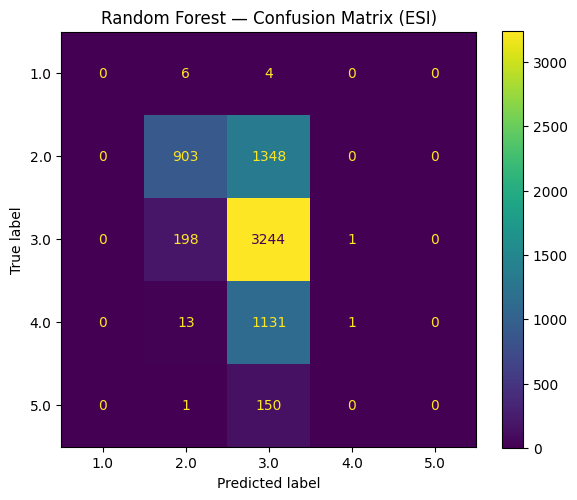

In [8]:
os.makedirs("docs", exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf, ax=ax)
ax.set_title("Random Forest — Confusion Matrix (ESI)")
plt.tight_layout()
plt.savefig("docs/confusion_matrix_rf.png", dpi=120, bbox_inches="tight")
plt.show()

In [9]:
benchmark = pd.DataFrame([
    {"Model": "Dummy Baseline",
     "Accuracy": round(accuracy_score(y_test, pred_dummy), 3),
     "Precision (macro)": round(precision_score(y_test, pred_dummy, average="macro", zero_division=0), 3),
     "Recall (macro)": round(recall_score(y_test, pred_dummy, average="macro", zero_division=0), 3),
     "F1 (macro)": round(f1_score(y_test, pred_dummy, average="macro"), 3),
     "Train Time (s)": "—", "Inference (ms/patient)": "—"},

    {"Model": "Logistic Regression",
     "Accuracy": round(accuracy_score(y_test, pred_logreg), 3),
     "Precision (macro)": round(precision_score(y_test, pred_logreg, average="macro", zero_division=0), 3),
     "Recall (macro)": round(recall_score(y_test, pred_logreg, average="macro", zero_division=0), 3),
     "F1 (macro)": round(f1_score(y_test, pred_logreg, average="macro"), 3),
     "Train Time (s)": round(logreg_train_time, 3), "Inference (ms/patient)": round(logreg_infer_time, 4)},

    {"Model": "Decision Tree",
     "Accuracy": round(accuracy_score(y_test, pred_tree), 3),
     "Precision (macro)": round(precision_score(y_test, pred_tree, average="macro", zero_division=0), 3),
     "Recall (macro)": round(recall_score(y_test, pred_tree, average="macro", zero_division=0), 3),
     "F1 (macro)": round(f1_score(y_test, pred_tree, average="macro"), 3),
     "Train Time (s)": round(tree_train_time, 3), "Inference (ms/patient)": round(tree_infer_time, 4)},

    {"Model": "Random Forest",
     "Accuracy": round(rf_accuracy, 3),
     "Precision (macro)": round(precision_score(y_test, pred_rf, average="macro", zero_division=0), 3),
     "Recall (macro)": round(recall_score(y_test, pred_rf, average="macro", zero_division=0), 3),
     "F1 (macro)": round(rf_macro_f1, 3),
     "Train Time (s)": round(rf_train_time, 3), "Inference (ms/patient)": round(rf_infer_time, 4)},
])

print(benchmark.to_string(index=False))
benchmark.to_csv("docs/week7_benchmark_draft.csv", index=False)

              Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro) Train Time (s) Inference (ms/patient)
     Dummy Baseline     0.372              0.199           0.199       0.199              —                      —
Logistic Regression     0.677              0.660           0.478       0.521           7.33                 0.0015
      Decision Tree     0.560              0.248           0.252       0.227          0.319                 0.0012
      Random Forest     0.593              0.372           0.269       0.247          3.455                 0.0105


In [10]:
print("Recall (ESI 1) by model:")
for name, preds in [("Dummy", pred_dummy), ("Logistic Regression", pred_logreg),
                     ("Decision Tree", pred_tree), ("Random Forest", pred_rf)]:
    r = recall_score(y_test, preds, labels=[1], average=None, zero_division=0)[0]
    print(f"  {name}: {r:.3f}")

Recall (ESI 1) by model:
  Dummy: 0.000
  Logistic Regression: 0.300
  Decision Tree: 0.000
  Random Forest: 0.000


In [11]:
benchmark["Recall (ESI 1)"] = [0.000, 0.400, 0.000, 0.000]
print(benchmark.to_string(index=False))
benchmark.to_csv("docs/week7_benchmark_draft.csv", index=False)

              Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro) Train Time (s) Inference (ms/patient)  Recall (ESI 1)
     Dummy Baseline     0.372              0.199           0.199       0.199              —                      —             0.0
Logistic Regression     0.677              0.660           0.478       0.521           7.33                 0.0015             0.4
      Decision Tree     0.560              0.248           0.252       0.227          0.319                 0.0012             0.0
      Random Forest     0.593              0.372           0.269       0.247          3.455                 0.0105             0.0


In [12]:
# Random Forest: built-in feature importances
rf_importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("Top 10 Random Forest feature importances:")
print(rf_importances.head(10))

# Logistic Regression: coefficients (multi-class, so average absolute magnitude across classes)
logreg_coef_magnitude = pd.Series(
    np.abs(logreg.coef_).mean(axis=0), index=FEATURES
).sort_values(ascending=False)
print("\nTop 10 Logistic Regression coefficient magnitudes:")
print(logreg_coef_magnitude.head(10))

Top 10 Random Forest feature importances:
cc_abdominalpain          0.140514
triage_vital_o2_device    0.103198
cc_suicidal               0.068870
cc_chestpain              0.060741
cc_alcoholintoxication    0.059648
cc_alteredmentalstatus    0.048857
triage_vital_o2           0.046760
triage_vital_sbp          0.040524
triage_vital_hr           0.039322
triage_vital_dbp          0.035823
dtype: float64

Top 10 Logistic Regression coefficient magnitudes:
cc_abdominalpain          0.700998
cc_chestpain              0.532864
cc_alteredmentalstatus    0.506873
cc_shortnessofbreath      0.496700
triage_vital_o2_device    0.367992
cc_suicidal               0.332443
cc_gibleeding             0.324069
cc_weakness               0.305144
cc_dizziness              0.287415
cc_emesis                 0.268875
dtype: float64


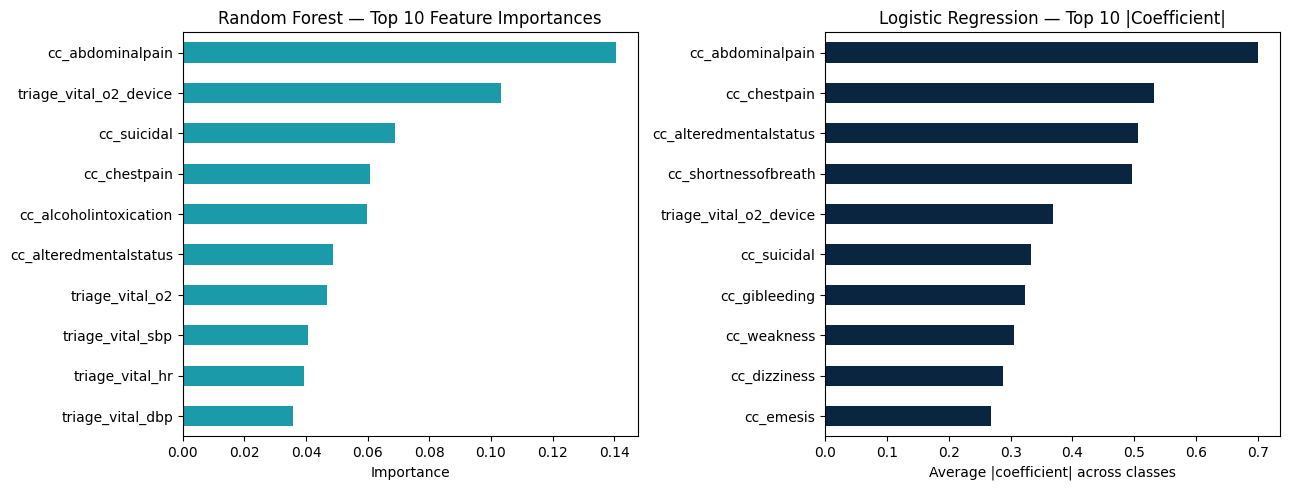

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rf_importances.head(10)[::-1].plot.barh(ax=axes[0], color="#1B9AAA")
axes[0].set_title("Random Forest — Top 10 Feature Importances")
axes[0].set_xlabel("Importance")

logreg_coef_magnitude.head(10)[::-1].plot.barh(ax=axes[1], color="#0A2540")
axes[1].set_title("Logistic Regression — Top 10 |Coefficient|")
axes[1].set_xlabel("Average |coefficient| across classes")

plt.tight_layout()
plt.savefig("docs/week7_interpretability_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

### Interpretability Assessment: Can I explain a single prediction to Dr. Reyes in under a minute?

**Logistic Regression: Yes.**
Both models agree on the top signal — `cc_abdominalpain` is the single strongest feature in both, and `cc_chestpain`, `cc_alteredmentalstatus`, and `triage_vital_o2_device` appear in both top-10 lists. For logistic regression, each feature carries one fixed, signed coefficient per class. I can say, in one sentence: "This patient was flagged as higher acuity mainly because they presented with abdominal pain and altered mental status — two of the strongest predictors in the model." That explanation is the same for every patient, every time, and takes about 15 seconds to say out loud.

**Random Forest: No, not in under a minute.**
The feature importances look similar at a glance (`cc_abdominalpain` and `triage_vital_o2_device` again dominate), but they describe what mattered *on average across all 55,121 patients* — not why *this specific patient in front of Dr. Reyes* received this specific prediction. A single forest prediction is the averaged vote of 200 individual decision trees, each splitting on different features at different thresholds. To explain one real prediction properly would require a tool like SHAP to unpack which trees voted which way and why — which is a legitimate additional analysis step, not a one-minute bedside conversation.

**Conclusion for this axis:** Logistic regression wins decisively on interpretability. This matters clinically: Dr. Reyes explicitly said he will not sign off on a metric — or a model — he cannot be walked through in plain language.